EX 3

[[ 3 -1  0  0 -1 -1  0  0  0  0]
 [-1  3 -1  0  0  0 -1  0  0  0]
 [ 0 -1  3 -1  0  0  0 -1  0  0]
 [ 0  0 -1  3 -1  0  0  0 -1  0]
 [-1  0  0 -1  3  0  0  0  0 -1]
 [-1  0  0  0  0  3  0 -1 -1  0]
 [ 0 -1  0  0  0  0  3  0 -1 -1]
 [ 0  0 -1  0  0 -1  0  3  0 -1]
 [ 0  0  0 -1  0 -1 -1  0  3  0]
 [ 0  0  0  0 -1  0 -1 -1  0  3]]


Text(0.5, 1.0, 'Graph Reconstructed from Laplacian Matrix')

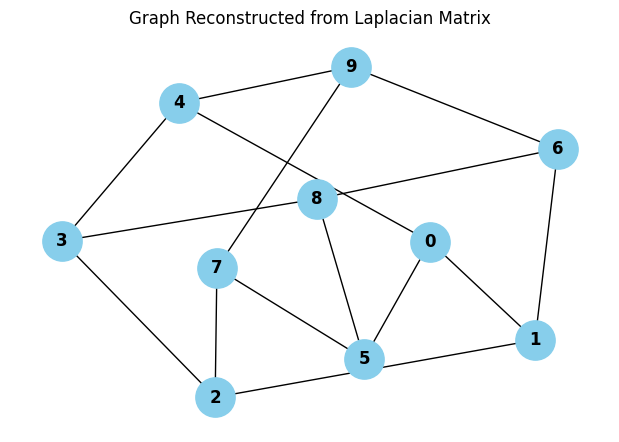

In [97]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

L = nx.petersen_graph()
L:np.ndarray = nx.laplacian_matrix(L).toarray()
print(L)


A = -L.copy()
np.fill_diagonal(A, 0)


G = nx.from_numpy_array(A)

plt.figure(figsize=(6, 4))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=800, font_weight='bold')
plt.title("Graph Reconstructed from Laplacian Matrix")


In [98]:

# print(np.linalg.eigvals(L))
np.set_printoptions(precision=4, suppress=True)
eigval, eigvec = np.linalg.eig(L)
print(eigval)
# print(sorted(np.round(eigval).astype(int).tolist()))
print(eigvec.T)

[ 5.  2. -0.  2.  5.  5.  5.  2.  2.  2.]
[[-0.6325  0.4216 -0.1054 -0.1054  0.4216  0.4216 -0.1054 -0.1054 -0.1054
  -0.1054]
 [ 0.7071  0.2357 -0.2357 -0.2357  0.2357  0.2357 -0.2357 -0.2357 -0.2357
  -0.2357]
 [-0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162
  -0.3162]
 [ 0.0229  0.4766 -0.0959 -0.5263 -0.4153 -0.0384  0.5496 -0.0463 -0.0151
   0.0881]
 [-0.0007  0.0024  0.3956 -0.4894  0.0921 -0.0931 -0.3996 -0.3042  0.491
   0.3058]
 [-0.0316  0.4815 -0.5507  0.3046 -0.2038 -0.2145 -0.3807  0.3153  0.1453
   0.1346]
 [ 0.002  -0.0607 -0.1412 -0.18    0.38   -0.3233  0.2607  0.5232  0.1213
  -0.5819]
 [-0.0215  0.0279  0.436   0.0675 -0.422   0.3725 -0.3866  0.3406  0.0535
  -0.468 ]
 [-0.0224  0.5808  0.2281  0.0579 -0.2841 -0.3191  0.375  -0.4106  0.1139
  -0.3196]
 [-0.1508  0.3922  0.5525 -0.0043 -0.0609 -0.4821 -0.0095  0.1646 -0.4959
   0.0942]]


the first two vectors have a lot of the same values


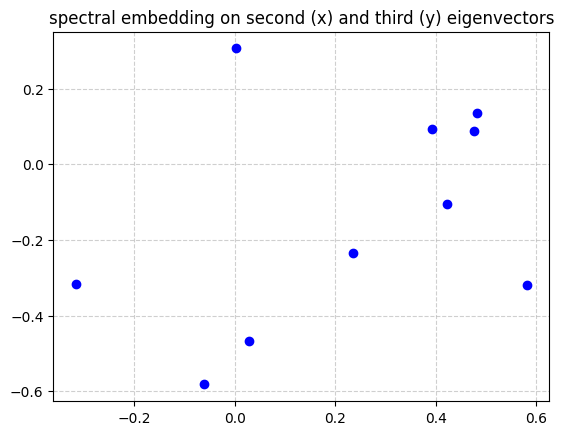

In [99]:
second = 1
third = 9

x_val = eigvec[second]
y_val = eigvec[third]


plt.plot(x_val,y_val, color="blue",marker='o',linestyle='none')
# plt.plot(x_val[keep],y_val[keep], color="red",marker='o',linestyle='none')


plt.title("spectral embedding on second (x) and third (y) eigenvectors")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [100]:
def sweeping_cut(L, v2):
    n = len(v2)
    sorted_indices = np.argsort(v2)
    
    best_ratio = float('inf')
    best_S = None
    best_boundary = None

    for i in range(1, n):
        S = sorted_indices[:i]
        V_minus_S = sorted_indices[i:]
        
        cut_submatrix = L[np.ix_(S, V_minus_S)]
        
        boundary_size = int(np.sum(cut_submatrix < 0)) 
        
        denominator = min(len(S), len(V_minus_S))
        ratio = boundary_size / denominator
        
        if ratio < best_ratio:
            best_ratio = ratio
            best_S = S.tolist()
            rows, cols = np.where(cut_submatrix < 0)
            best_boundary = [(S[r], V_minus_S[c]) for r, c in zip(rows, cols)]
                        
    best_S = np.array(best_S).tolist()
    best_boundary = np.array(best_boundary).tolist()
                        
    return best_S, best_boundary, best_ratio

S, boundary, ratio = sweeping_cut(L, eigvec[1])



print("\n--- Final Result ---")
print(f"Optimal Set S: {S}")
print(f"Boundary Edges: {boundary}")
print(f"Isoperimetric Ratio: {ratio}")


--- Final Result ---
Optimal Set S: [2, 6, 4, 7, 1, 9]
Boundary Edges: [[2, 3], [6, 8], [4, 0], [4, 3], [7, 5], [1, 0]]
Isoperimetric Ratio: 1.5


the isoperimetric ratio is 1.5 but we know we can do better ratio of 1. all the center nodes as S gives an isoperimetric ratio of $5/5 = 1$

In [101]:


L[0][0] = 1
L[0][1] = 0
L[0][4] = 0
L[1][0] = 0
L[4][0] = 0

L[1][1] = 2
L[4][4]  =2

print(L)

[[ 1  0  0  0  0 -1  0  0  0  0]
 [ 0  2 -1  0  0  0 -1  0  0  0]
 [ 0 -1  3 -1  0  0  0 -1  0  0]
 [ 0  0 -1  3 -1  0  0  0 -1  0]
 [ 0  0  0 -1  2  0  0  0  0 -1]
 [-1  0  0  0  0  3  0 -1 -1  0]
 [ 0 -1  0  0  0  0  3  0 -1 -1]
 [ 0  0 -1  0  0 -1  0  3  0 -1]
 [ 0  0  0 -1  0 -1 -1  0  3  0]
 [ 0  0  0  0 -1  0 -1 -1  0  3]]


In [102]:

# print(np.linalg.eigvals(L))
np.set_printoptions(precision=4, suppress=True)
eigval, eigvec = np.linalg.eig(L)
print(eigval)
# print(sorted(np.round(eigval).astype(int).tolist()))
print(eigvec.T)

[5.     0.     0.5858 2.     3.4142 1.2679 2.     4.7321 5.     2.    ]
[[-0.138  -0.138   0.207   0.207  -0.138   0.5521  0.207  -0.483  -0.483
   0.207 ]
 [-0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162 -0.3162
  -0.3162]
 [-0.8125  0.238   0.1683  0.1683  0.238  -0.3366  0.1683  0.      0.
   0.1683]
 [-0.4082 -0.4082 -0.     -0.     -0.4082  0.4082 -0.      0.4082  0.4082
  -0.    ]
 [ 0.2326 -0.3971  0.2808  0.2808 -0.3971 -0.5615  0.2808  0.     -0.
   0.2808]
 [ 0.      0.628   0.2299 -0.2299 -0.628  -0.      0.2299  0.     -0.
  -0.2299]
 [-0.0385 -0.0385 -0.3595  0.2087 -0.0385  0.0385  0.3595 -0.5296  0.6067
  -0.2087]
 [-0.     -0.3251  0.444  -0.444   0.3251  0.      0.444  -0.      0.
  -0.444 ]
 [-0.0031 -0.0031 -0.4034  0.4128 -0.0031  0.0125  0.4128  0.3972 -0.4191
  -0.4034]
 [ 0.0141  0.0141 -0.5034 -0.4959  0.0141 -0.0141  0.5034 -0.0216 -0.0065
   0.4959]]


much of the symmetry is lost.
4th eigenvector still has good symmetry, and final one also has a lot of repeated values

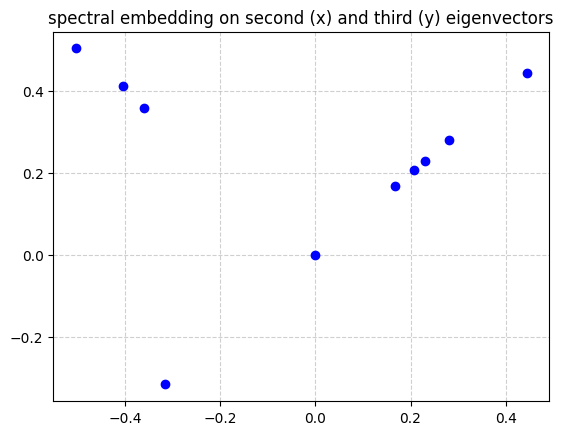

In [103]:
second = 2
third = 6

x_val = eigvec[second]
y_val = eigvec[third]


plt.plot(x_val,y_val, color="blue",marker='o',linestyle='none')
# plt.plot(x_val[keep],y_val[keep], color="red",marker='o',linestyle='none')

plt.title("spectral embedding on second (x) and third (y) eigenvectors")


plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [104]:
S, boundary, ratio = sweeping_cut(L, eigvec[2])



print("\n--- Final Result ---")
print(f"Optimal Set S: {S}")
print(f"Boundary Edges: {boundary}")
print(f"Isoperimetric Ratio: {ratio}")


--- Final Result ---
Optimal Set S: [9, 8, 6, 1, 3]
Boundary Edges: [[9, 4], [9, 7], [8, 5], [1, 2], [3, 2], [3, 4]]
Isoperimetric Ratio: 1.2


this is definitely not the optimal as choosing eigenvector $5$ gives an isoperimetric ratio of 1. I think it can go even lower though. 